# A Book-Style Tutorial on Financial Backtesting, Stress Testing, and Causal Thinking

This notebook is intentionally written like a slow, careful chapter in a textbook.

It is for two audiences at the same time:

1. a finance beginner who wants to understand what prices, returns, factors, backtests, and benchmarks mean,
2. a causality beginner who wants to understand what a counterfactual is, what this notebook can and cannot prove, and why predictive success is not the same thing as causal truth.

We will do six things:

1. retrieve financial data,
2. explore the raw data visually,
3. engineer trading factors step by step,
4. plug those factors into an algorithmic trading system,
5. run counterfactual-style stress scenarios,
6. test the strategy again on the most recent market window.

The notebook is deliberately verbose. Code is broken into small cells, lines are commented heavily, and the explanations aim to go beyond the minimum.

## How to Read This Notebook

Think of the notebook as a short book with parts and chapters:

- **Part I. Setup**
  We import libraries, explain what each one does, and choose our research settings.
- **Part II. Raw Data**
  We download market data, inspect it, and check whether it looks trustworthy.
- **Part III. Factor Engineering**
  We turn raw prices and volume into features that a strategy can use.
- **Part IV. Exploratory Analysis**
  We visualize the factors before modeling them.
- **Part V. Train/Test Logic**
  We explain time splits and leakage risk.
- **Part VI. Backtesting**
  We fit a trading system and turn predictions into positions and returns.
- **Part VII. Factor Interpretation**
  We ask which factors the model used most heavily.
- **Part VIII. Counterfactual Stress Analysis**
  We perturb the features in scenario form and see how the strategy responds.
- **Part IX. Recent Re-Test**
  We isolate the most recent window to see whether recent behavior still looks acceptable.
- **Part X. Interpretation and Limitations**
  We close by separating useful evidence from over-claiming.

## Vocabulary Before We Touch the Code

A few beginner-friendly definitions:

- **Ticker**: the short symbol used to identify an asset, such as `AAPL` for Apple.
- **OHLCV data**: the standard columns in market data.
  `Open`, `High`, `Low`, `Close`, and `Volume`.
- **Return**: the percentage change in price.
  If a stock goes from 100 to 101, the return is 1%.
- **Factor / feature**: a variable we think might help explain or predict future returns.
  In this notebook, examples include momentum, volatility, trend gap, and RSI.
- **Target**: the future quantity we try to predict.
  Here it is a 5-day forward return.
- **Backtest**: a historical simulation where we pretend we were trading in the past using only information that would have been available at that time.
- **Benchmark**: a simpler reference strategy used for comparison.
  Here we use an equal-weight market-style benchmark over the same universe.
- **Drawdown**: the percentage drop from a previous peak in the equity curve.
- **Counterfactual**: a “what if the world had looked different?” question.
- **Causality**: the study of what truly causes what, not merely what correlates with what.

The last two ideas matter a lot.
This notebook does **not** run a randomized experiment on markets.
It uses observational data.
That means the stress analysis below is best understood as **counterfactual-style scenario analysis**, not a proof of causal structure.

# Part I. Setup

## Chapter 1. Import the Tools and Explain Every Library

Good research notebooks do not just import things and move on.
They explain why each tool exists.

In [1]:
from pathlib import Path  # Path gives us safe, readable filesystem paths.
import sys  # sys lets us modify Python's import search path.
import warnings  # warnings lets us quiet noisy library messages during teaching.

from IPython.display import display  # display renders rich tables and objects nicely inside notebooks.
import matplotlib.pyplot as plt  # Matplotlib is the foundational plotting library.
import numpy as np  # NumPy gives us fast numerical arrays and math operations.
import pandas as pd  # pandas gives us DataFrames, the main table object used in this notebook.
import seaborn as sns  # seaborn makes statistical plots look cleaner and easier to build.

NOTEBOOK_DIR = Path.cwd().resolve()  # This is the folder from which the notebook is running.
ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parents[0]  # This finds the project root robustly.

if str(ROOT) not in sys.path:  # If Python cannot yet import our local project modules...
    sys.path.insert(0, str(ROOT))  # ...prepend the project root so local imports work.

from src.backtesting_system import AlgorithmicTradingSystem  # Our reusable trading system class.
from src.backtesting_system import apply_counterfactual  # Our feature-shock helper for scenario analysis.
from src.backtesting_system import compute_factor_importance  # Our permutation-importance helper.
from src.backtesting_system import evaluate_performance  # Our performance-metric helper.
from src.backtesting_system import fetch_price_data  # Our market-data retrieval helper.
from src.backtesting_system import summarize_recent_window  # Our helper for the recent-window re-test.

warnings.filterwarnings("ignore")  # We suppress noisy warnings so the teaching signal stays visible.

pd.set_option("display.max_columns", 80)  # Show more columns before pandas truncates the view.
pd.set_option("display.width", 180)  # Make wide tables easier to read in notebook output.
sns.set_theme(style="whitegrid", context="talk")  # Use a clean plotting theme for explanation-heavy work.

## Chapter 2. Choose the Research Universe and the Time Horizon

Before downloading data we must decide:

- which assets we want to study,
- how far back to go,
- where the out-of-sample test period begins,
- and how much “recent data” counts as recent for the final re-test.

We deliberately use a mixed equity universe rather than a single stock.
That makes the cross-sectional ranking strategy more meaningful.

In [2]:
symbols = [  # A mixed universe helps the ranking model compare assets against one another.
    "AAPL",  # Apple
    "MSFT",  # Microsoft
    "NVDA",  # Nvidia
    "AMZN",  # Amazon
    "META",  # Meta
    "JPM",   # JPMorgan
    "XOM",   # Exxon Mobil
    "LLY",   # Eli Lilly
    "UNH",   # UnitedHealth
    "CAT",   # Caterpillar
    "SPY",   # S&P 500 ETF
    "QQQ",   # Nasdaq-100 ETF
]

start_date = "2018-01-01"  # We start early enough to cover multiple market regimes.
test_start = "2024-01-01"  # Everything from this date onward will be treated as out-of-sample.
recent_months = 6  # At the end we will isolate the most recent six months.
trading_days_per_year = 252  # This is the market convention for annualizing daily data.

print("Number of symbols:", len(symbols))
print("First few symbols:", symbols[:5])
print("Train/Test split date:", test_start)

Number of symbols: 12
First few symbols: ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'META']
Train/Test split date: 2024-01-01


# Part II. Retrieve and Inspect the Raw Data

## Chapter 3. Download the Historical Market Data

We use the helper function `fetch_price_data`, which internally uses `yfinance`.

Why not start from the strategy immediately?
Because data quality problems are one of the fastest ways to ruin an analysis.
The first responsibility of a backtest is to earn the right to be trusted.

In [3]:
raw_data = fetch_price_data(  # Ask the helper to download OHLCV data.
    symbols=symbols,  # Use the symbol list chosen above.
    start=start_date,  # Download data from the chosen start date onward.
)

raw_data = raw_data.sort_values(["symbol", "date"]).reset_index(drop=True)  # Sort cleanly for all later rolling calculations.

print("Raw data shape:", raw_data.shape)
print("First available date:", raw_data["date"].min())
print("Last available date:", raw_data["date"].max())

raw_data.head(10)

Raw data shape: (24912, 7)
First available date: 2018-01-02 00:00:00
Last available date: 2026-04-07 00:00:00


,date,open,high,low,close,volume,symbol
0,2018-01-02,39.812832,40.313533,39.602254,40.304173,102223600,AAPL
1,2018-01-03,40.367350,40.839976,40.233987,40.297157,118071600,AAPL
2,2018-01-04,40.369693,40.587289,40.262067,40.484341,89738400,AAPL
3,2018-01-05,40.580269,41.031836,40.489020,40.945267,94640000,AAPL
4,2018-01-08,40.793190,41.087995,40.694918,40.793190,82271200,AAPL
5,2018-01-09,40.839976,40.959301,40.573247,40.788502,86336000,AAPL
6,2018-01-10,40.514753,40.781482,40.477317,40.779140,95839600,AAPL
7,2018-01-11,40.849335,41.059912,40.825939,41.010777,74670800,AAPL
8,2018-01-12,41.221345,41.497435,41.097340,41.434261,101672400,AAPL
9,2018-01-16,41.623782,41.972403,41.211991,41.223690,118263600,AAPL


In [4]:
raw_data.tail(10)

,date,open,high,low,close,volume,symbol
24902,2026-03-24,161.710007,167.479996,161.250000,165.380005,26131800,XOM
24903,2026-03-25,163.869995,165.000000,162.929993,163.259995,17192300,XOM
24904,2026-03-26,164.089996,165.679993,162.059998,165.429993,18625200,XOM
24905,2026-03-27,165.580002,171.229996,164.800003,170.990005,30338300,XOM
24906,2026-03-30,172.509995,176.410004,171.050003,171.470001,29813500,XOM
24907,2026-03-31,172.669998,174.380005,165.970001,169.660004,32006700,XOM
24908,2026-04-01,165.770004,168.000000,159.529999,160.779999,37927600,XOM
24909,2026-04-02,164.490005,166.899994,159.589996,160.690002,25377700,XOM
24910,2026-04-06,160.570007,163.750000,159.529999,163.369995,16344300,XOM
24911,2026-04-07,164.220001,166.240005,161.770004,163.910004,25227500,XOM


## Chapter 4. Check Coverage by Symbol

A multi-asset notebook should always confirm:

- when each symbol starts,
- when each symbol ends,
- and whether each symbol has roughly the expected number of rows.

This matters because irregular coverage can quietly bias both factor construction and backtest results.

In [5]:
coverage_summary = (
    raw_data.groupby("symbol")
    .agg(
        first_date=("date", "min"),
        last_date=("date", "max"),
        observations=("date", "count"),
        min_close=("close", "min"),
        max_close=("close", "max"),
    )
    .sort_index()
)

coverage_summary

,first_date,last_date,observations,min_close,max_close
symbol,,,,,
AAPL,2018-01-02,2026-04-07,2076,33.768074,285.922455
AMZN,2018-01-02,2026-04-07,2076,59.450500,254.000000
CAT,2018-01-02,2026-04-07,2076,81.455406,775.000000
JPM,2018-01-02,2026-04-07,2076,66.763313,332.906250
LLY,2018-01-02,2026-04-07,2076,65.750267,1108.090454
META,2018-01-02,2026-04-07,2076,88.217712,788.148987
MSFT,2018-01-02,2026-04-07,2076,78.007797,539.825256
NVDA,2018-01-02,2026-04-07,2076,3.150397,207.017273
QQQ,2018-01-02,2026-04-07,2076,137.163391,634.152344


## Chapter 5. Visualize the Raw Price Paths

Raw prices of different assets live on very different scales.
Apple is not directly comparable to SPY in dollar level alone.

To compare them visually, we normalize each asset to start at 1.
Then a value of 1.80 means “up 80% since the beginning of the sample,” regardless of the original price level.

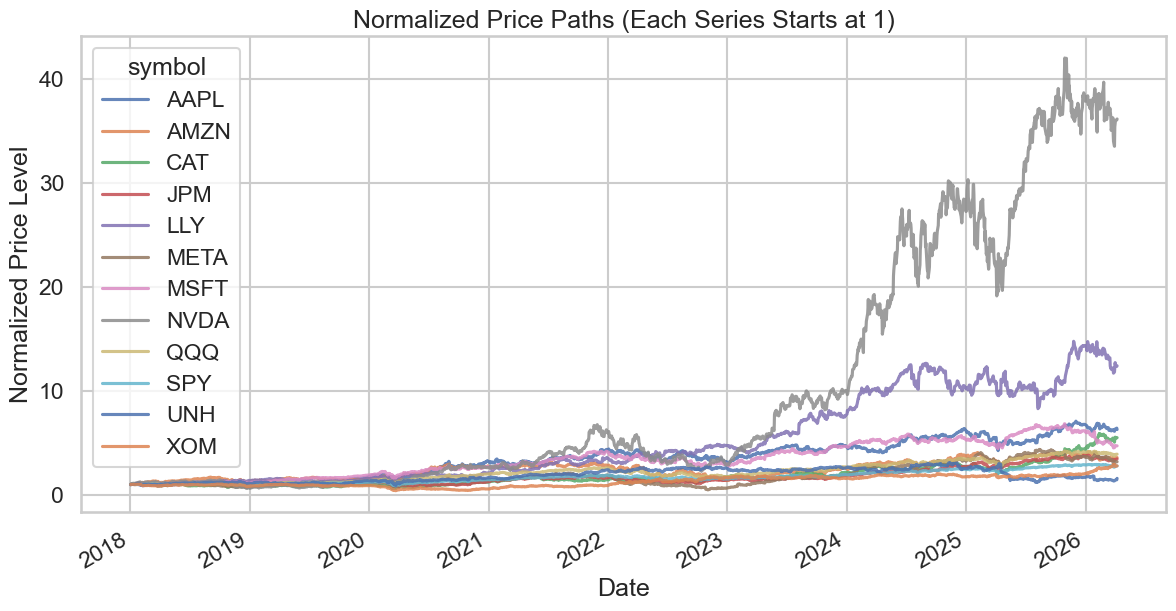

In [6]:
price_pivot = raw_data.pivot(index="date", columns="symbol", values="close")  # Turn long-form prices into a wide date-by-symbol matrix.

first_valid_prices = price_pivot.apply(  # Find each symbol's own first valid close.
    lambda column: column.dropna().iloc[0] if column.notna().any() else np.nan
)

normalized_prices = price_pivot.divide(first_valid_prices, axis=1)  # Divide every column by its own first valid price.

ax = normalized_prices.plot(  # Plot all normalized price paths together.
    figsize=(14, 7),
    title="Normalized Price Paths (Each Series Starts at 1)",
    alpha=0.85,
)
ax.set_ylabel("Normalized Price Level")
ax.set_xlabel("Date")
plt.show()

## Chapter 6. Convert Prices into Daily Returns

Finance beginners often ask:
“Why do quants use returns instead of raw prices?”

Because returns are scale-free.
A 1% move means the same thing whether the stock price is 20 or 200.

We compute a one-day percentage return for each symbol:

\[
r_t = \frac{P_t}{P_{t-1}} - 1
\]

In [7]:
raw_data["return_1d"] = raw_data.groupby("symbol")["close"].pct_change()  # Compute one-day percentage returns within each symbol.

raw_data[["date", "symbol", "close", "return_1d"]].head(12)

,date,symbol,close,return_1d
0,2018-01-02,AAPL,40.304173,NaN
1,2018-01-03,AAPL,40.297157,-0.000174
2,2018-01-04,AAPL,40.484341,0.004645
3,2018-01-05,AAPL,40.945267,0.011385
4,2018-01-08,AAPL,40.793190,-0.003714
5,2018-01-09,AAPL,40.788502,-0.000115
6,2018-01-10,AAPL,40.779140,-0.000230
7,2018-01-11,AAPL,41.010777,0.005680
8,2018-01-12,AAPL,41.434261,0.010326
9,2018-01-16,AAPL,41.223690,-0.005082


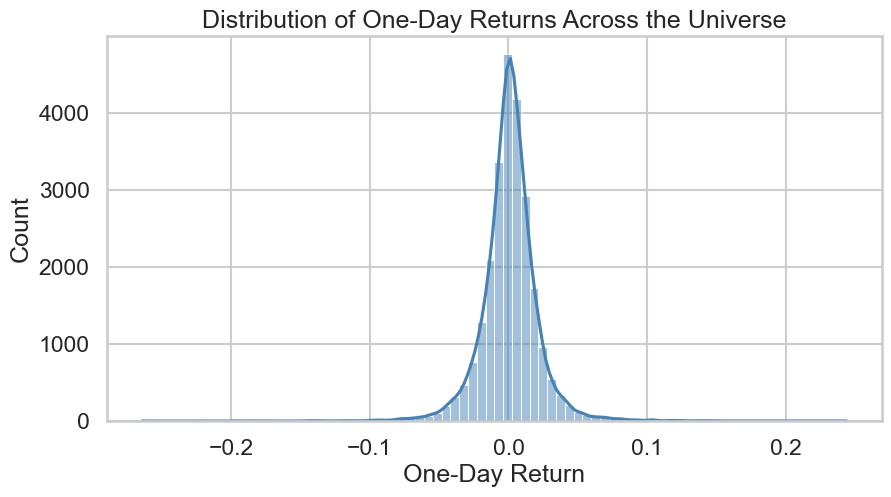

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(  # A histogram shows the distribution of daily returns.
    raw_data["return_1d"].dropna(),
    bins=80,
    kde=True,
    color="steelblue",
)
plt.title("Distribution of One-Day Returns Across the Universe")
plt.xlabel("One-Day Return")
plt.ylabel("Count")
plt.show()

## Chapter 7. Check for Missing Values and Oddities

This is boring work.
It is also what separates credible analysis from fragile analysis.

Missing prices, zero volumes, and partial downloads can propagate into rolling features and create misleading results.

In [9]:
missing_summary = raw_data.isna().sum().sort_values(ascending=False)  # Count missing values in every column.

missing_summary[missing_summary > 0]

return_1d    12
dtype: int64

In [10]:
sample_symbol = "AAPL"  # We will inspect one symbol closely as a sanity check.

raw_data.query("symbol == @sample_symbol")[["date", "close", "volume", "return_1d"]].tail(15)

,date,close,volume,return_1d
2061,2026-03-17,254.229996,32361600,0.005577
2062,2026-03-18,249.940002,35757900,-0.016874
2063,2026-03-19,248.960007,34864100,-0.003921
2064,2026-03-20,247.990005,88331100,-0.003896
2065,2026-03-23,251.490005,40546100,0.014113
2066,2026-03-24,251.639999,45152300,0.000596
2067,2026-03-25,252.619995,28476700,0.003894
2068,2026-03-26,252.889999,41796700,0.001069
2069,2026-03-27,248.800003,47900000,-0.016173
2070,2026-03-30,246.630005,39446200,-0.008722


# Part III. Engineer the Trading Factors Slowly

## Chapter 8. Why Factors Exist

A factor is a distilled signal extracted from raw data.

Instead of handing the model raw prices and hoping for the best, we transform the data into quantities with economic or behavioral meaning:

- **Momentum**: has the asset been going up recently?
- **Trend gap**: is the short moving average above the long moving average?
- **Volatility**: how choppy or unstable has the asset been?
- **Liquidity / volume surprise**: is trading activity unusually high or low?
- **RSI**: is the asset recently overbought or oversold?

We will build each feature in separate steps.

## Chapter 9. Start from a Fresh Working Table

We create a new table so that feature engineering does not mutate the original raw dataset in a confusing way.

In [11]:
factor_data = raw_data.copy()  # Work on a copy so the raw table stays intact.

factor_data = factor_data.sort_values(["symbol", "date"]).reset_index(drop=True)  # Sorting matters before rolling windows.

grouped_close = factor_data.groupby("symbol")["close"]  # This grouped Series lets us compute symbol-specific rolling features.
grouped_volume = factor_data.groupby("symbol")["volume"]  # We keep grouped volume for later liquidity calculations.

factor_data.head(5)

,date,open,high,low,close,volume,symbol,return_1d
0,2018-01-02,39.812832,40.313533,39.602254,40.304173,102223600,AAPL,NaN
1,2018-01-03,40.367350,40.839976,40.233987,40.297157,118071600,AAPL,-0.000174
2,2018-01-04,40.369693,40.587289,40.262067,40.484341,89738400,AAPL,0.004645
3,2018-01-05,40.580269,41.031836,40.489020,40.945267,94640000,AAPL,0.011385
4,2018-01-08,40.793190,41.087995,40.694918,40.793190,82271200,AAPL,-0.003714


## Chapter 10. Compute Short-Horizon and Medium-Horizon Returns

Returns over multiple horizons give us a simple momentum view.

Intuition:

- `return_5d` asks: “How much has this asset moved over roughly one trading week?”
- `return_21d` asks: “How much has this asset moved over roughly one trading month?”

In [12]:
factor_data["return_5d"] = grouped_close.pct_change(5)  # Five-day momentum.
factor_data["return_21d"] = grouped_close.pct_change(21)  # Twenty-one-day momentum.

factor_data[["date", "symbol", "close", "return_5d", "return_21d"]].head(12)

,date,symbol,close,return_5d,return_21d
0,2018-01-02,AAPL,40.304173,NaN,NaN
1,2018-01-03,AAPL,40.297157,NaN,NaN
2,2018-01-04,AAPL,40.484341,NaN,NaN
3,2018-01-05,AAPL,40.945267,NaN,NaN
4,2018-01-08,AAPL,40.793190,NaN,NaN
5,2018-01-09,AAPL,40.788502,0.012017,NaN
6,2018-01-10,AAPL,40.779140,0.011961,NaN
7,2018-01-11,AAPL,41.010777,0.013003,NaN
8,2018-01-12,AAPL,41.434261,0.011943,NaN
9,2018-01-16,AAPL,41.223690,0.010553,NaN


## Chapter 11. Build Moving Averages and the Trend Gap

A moving average smooths noisy day-to-day changes.

We use:

- a 10-day moving average for the short trend,
- a 50-day moving average for the longer trend.

Then we define:

\[
\text{trend gap} = \frac{SMA_{10}}{SMA_{50}} - 1
\]

If this value is positive, the short trend is above the longer trend.

In [13]:
factor_data["sma_10"] = grouped_close.transform(  # Compute the 10-day simple moving average.
    lambda series: series.rolling(10).mean()
)

factor_data["sma_50"] = grouped_close.transform(  # Compute the 50-day simple moving average.
    lambda series: series.rolling(50).mean()
)

factor_data["trend_gap"] = factor_data["sma_10"] / factor_data["sma_50"] - 1  # Convert the moving-average relation into a scale-free feature.

factor_data[["date", "symbol", "close", "sma_10", "sma_50", "trend_gap"]].tail(12)

,date,symbol,close,sma_10,sma_50,trend_gap
24900,2026-03-20,XOM,159.669998,155.125999,144.505345,0.073497
24901,2026-03-23,XOM,161.130005,156.195000,145.286021,0.075086
24902,2026-03-24,XOM,165.380005,157.920000,146.117923,0.080771
24903,2026-03-25,XOM,163.259995,159.087999,146.918947,0.082828
24904,2026-03-26,XOM,165.429993,160.277998,147.713504,0.085060
24905,2026-03-27,XOM,170.990005,161.764999,148.546546,0.088985
24906,2026-03-30,XOM,171.470001,163.189000,149.410446,0.092219
24907,2026-03-31,XOM,169.660004,164.274001,150.223047,0.093534
24908,2026-04-01,XOM,160.779999,164.593001,150.846722,0.091127
24909,2026-04-02,XOM,160.690002,164.846001,151.406016,0.088768


## Chapter 12. Estimate Rolling Volatility

Volatility is not direction.
It is variability.

Highly volatile assets can be exciting, but they can also be risky and unstable.

We estimate 20-day rolling volatility from one-day returns and annualize it using the market convention of 252 trading days:

\[
\sigma_{20} = \text{std}(r_{t-19}, \dots, r_t) \times \sqrt{252}
\]

In [14]:
factor_data["vol_20"] = factor_data.groupby("symbol")["return_1d"].transform(  # Work within each symbol separately.
    lambda series: series.rolling(20).std() * np.sqrt(trading_days_per_year)  # Rolling standard deviation, then annualize.
)

factor_data[["date", "symbol", "return_1d", "vol_20"]].head(12)

,date,symbol,return_1d,vol_20
0,2018-01-02,AAPL,NaN,NaN
1,2018-01-03,AAPL,-0.000174,NaN
2,2018-01-04,AAPL,0.004645,NaN
3,2018-01-05,AAPL,0.011385,NaN
4,2018-01-08,AAPL,-0.003714,NaN
5,2018-01-09,AAPL,-0.000115,NaN
6,2018-01-10,AAPL,-0.000230,NaN
7,2018-01-11,AAPL,0.005680,NaN
8,2018-01-12,AAPL,0.010326,NaN
9,2018-01-16,AAPL,-0.005082,NaN


## Chapter 13. Turn Raw Volume into a Relative Liquidity Signal

Raw volume levels differ dramatically across assets.
Comparing raw share counts directly is not very meaningful.

So we:

1. take the logarithm of volume,
2. compare current log-volume to its recent rolling mean,
3. scale that deviation by the rolling standard deviation.

The result is a **z-score**:

- positive values mean volume is unusually high,
- negative values mean volume is unusually low.

In [15]:
factor_data["log_volume"] = np.log(  # Take logs because trading volume is typically very skewed.
    factor_data["volume"].replace(0, np.nan)  # Replace zeros first so the logarithm is well-defined.
)

grouped_log_volume = factor_data.groupby("symbol")["log_volume"]  # Group log-volume by symbol for rolling statistics.

rolling_log_volume_mean = grouped_log_volume.transform(  # Recent average level of log-volume.
    lambda series: series.rolling(20).mean()
)

rolling_log_volume_std = grouped_log_volume.transform(  # Recent variability of log-volume.
    lambda series: series.rolling(20).std()
)

factor_data["volume_z"] = (  # Standardized liquidity surprise.
    factor_data["log_volume"] - rolling_log_volume_mean
) / rolling_log_volume_std

factor_data[["date", "symbol", "volume", "log_volume", "volume_z"]].head(12)

,date,symbol,volume,log_volume,volume_z
0,2018-01-02,AAPL,102223600,18.442673,NaN
1,2018-01-03,AAPL,118071600,18.586802,NaN
2,2018-01-04,AAPL,89738400,18.312409,NaN
3,2018-01-05,AAPL,94640000,18.365591,NaN
4,2018-01-08,AAPL,82271200,18.225532,NaN
5,2018-01-09,AAPL,86336000,18.273757,NaN
6,2018-01-10,AAPL,95839600,18.378187,NaN
7,2018-01-11,AAPL,74670800,18.128600,NaN
8,2018-01-12,AAPL,101672400,18.437266,NaN
9,2018-01-16,AAPL,118263600,18.588427,NaN


## Chapter 14. Compute RSI, a Popular Technical Indicator

RSI stands for **Relative Strength Index**.

Finance beginners usually encounter it as a way to summarize whether recent price changes have been more upward than downward.

The usual interpretation is:

- RSI above 70: maybe overbought,
- RSI below 30: maybe oversold.

Those rules are not laws of nature.
They are heuristics.

We calculate RSI from average gains and average losses over a 14-day window.

In [16]:
factor_data["price_change"] = grouped_close.diff()  # Day-to-day dollar price change.

factor_data["positive_change"] = factor_data["price_change"].clip(lower=0)  # Keep only gains; replace losses with zero.
factor_data["negative_change"] = (-factor_data["price_change"].clip(upper=0))  # Keep only the magnitude of losses.

factor_data["avg_gain_14"] = factor_data.groupby("symbol")["positive_change"].transform(  # Average gain over the last 14 days.
    lambda series: series.rolling(14).mean()
)

factor_data["avg_loss_14"] = factor_data.groupby("symbol")["negative_change"].transform(  # Average loss over the last 14 days.
    lambda series: series.rolling(14).mean()
)

relative_strength = factor_data["avg_gain_14"] / factor_data["avg_loss_14"].replace(0, np.nan)  # RS = average gain divided by average loss.

factor_data["rsi_14"] = 100 - (100 / (1 + relative_strength))  # Convert relative strength into the standard RSI scale.

factor_data[["date", "symbol", "price_change", "avg_gain_14", "avg_loss_14", "rsi_14"]].tail(12)

,date,symbol,price_change,avg_gain_14,avg_loss_14,rsi_14
24900,2026-03-20,XOM,1.509995,1.010714,0.621428,61.925600
24901,2026-03-23,XOM,1.460007,1.115000,0.450714,71.213512
24902,2026-03-24,XOM,4.250000,1.418571,0.307143,82.201977
24903,2026-03-25,XOM,-2.120010,1.351430,0.458572,74.664536
24904,2026-03-26,XOM,2.169998,1.474286,0.458572,76.274906
24905,2026-03-27,XOM,5.560013,1.871429,0.403572,82.260580
24906,2026-03-30,XOM,0.479996,1.905715,0.238572,88.874053
24907,2026-03-31,XOM,-1.809998,1.659286,0.367858,81.853399
24908,2026-04-01,XOM,-8.880005,1.520001,1.002144,60.266205
24909,2026-04-02,XOM,-0.089996,1.335001,1.008572,56.964345


## Chapter 15. Define the Prediction Target

A supervised model needs a target.

Here the target is the **5-day forward return**:

\[
\text{forward return}_{5d} = \frac{P_{t+5}}{P_t} - 1
\]

This is not the same thing as tomorrow's return.
We are asking the model to look at today's factors and estimate the next trading week's move.

In [17]:
factor_data["forward_return_5d"] = grouped_close.shift(-5) / factor_data["close"] - 1  # Future five-day return from today's perspective.

factor_data[["date", "symbol", "close", "forward_return_5d"]].head(12)

,date,symbol,close,forward_return_5d
0,2018-01-02,AAPL,40.304173,0.012017
1,2018-01-03,AAPL,40.297157,0.011961
2,2018-01-04,AAPL,40.484341,0.013003
3,2018-01-05,AAPL,40.945267,0.011943
4,2018-01-08,AAPL,40.793190,0.010553
5,2018-01-09,AAPL,40.788502,0.027362
6,2018-01-10,AAPL,40.779140,0.028516
7,2018-01-11,AAPL,41.010777,0.018142
8,2018-01-12,AAPL,41.434261,-0.000508
9,2018-01-16,AAPL,41.223690,0.004824


## Chapter 16. Keep a Clean Modeling Table

Rolling features create missing values at the start of each symbol's history.
The forward return target creates missing values at the end.

That is normal.
We now keep only the columns we need and drop rows that are incomplete.

In [18]:
feature_columns = [  # These are the factors we will hand to the model.
    "return_5d",
    "return_21d",
    "trend_gap",
    "vol_20",
    "volume_z",
    "rsi_14",
]

kept_columns = [  # These are the columns we want to retain for modeling and interpretation.
    "date",
    "symbol",
    "close",
    "volume",
    "return_1d",
    *feature_columns,
    "forward_return_5d",
]

model_data = factor_data[kept_columns].replace([np.inf, -np.inf], np.nan)  # Replace infinite values before dropping missing rows.
model_data = model_data.dropna().reset_index(drop=True)  # Keep only complete cases.

print("Modeling table shape:", model_data.shape)
model_data.head(10)

Modeling table shape: (24257, 12)


,date,symbol,close,volume,return_1d,return_5d,return_21d,trend_gap,vol_20,volume_z,rsi_14,forward_return_5d
0,2018-03-14,AAPL,41.920341,117473600,-0.008501,0.019482,0.096675,0.033338,0.201436,-0.810849,62.364585,-0.040181
1,2018-03-15,AAPL,41.969685,90975200,0.001177,0.009664,0.087076,0.034608,0.194452,-1.799108,57.418882,-0.054856
2,2018-03-16,AAPL,41.821674,157618800,-0.003527,-0.010890,0.063632,0.034879,0.159354,0.891392,47.417045,-0.073475
3,2018-03-19,AAPL,41.182674,133787200,-0.015279,-0.035329,0.013353,0.033639,0.169494,0.103828,42.474433,-0.014432
4,2018-03-20,AAPL,41.168579,78597600,-0.000342,-0.026282,0.016296,0.032695,0.168829,-2.184952,42.913331,-0.039374
5,2018-03-21,AAPL,40.235931,148219600,-0.022654,-0.040181,-0.003375,0.030797,0.187922,0.677688,41.190372,-0.027968
6,2018-03-22,AAPL,39.667400,165963200,-0.014130,-0.054856,-0.012977,0.026669,0.191768,1.085596,33.556658,-0.006337
7,2018-03-23,AAPL,38.748837,164115200,-0.023157,-0.073475,-0.043826,0.018956,0.194192,0.969219,26.869197,0.010549
8,2018-03-26,AAPL,40.588322,150164800,0.047472,-0.014432,-0.015555,0.013964,0.253240,0.595966,44.154675,-0.025352
9,2018-03-27,AAPL,39.547592,163690400,-0.025641,-0.039374,-0.059395,0.008142,0.267213,0.944263,40.746919,0.019425


# Part IV. Explore the Engineered Factors

## Chapter 17. Basic Summary Statistics

Before fitting any model, ask:

- Are the features on sensible ranges?
- Are any columns suspiciously constant?
- Do we see extreme tails?

This is one of the simplest and most useful habits in quantitative work.

In [19]:
model_data[feature_columns + ["forward_return_5d"]].describe().T

,count,mean,std,min,25%,50%,75%,max
return_5d,24257.0,0.004635,0.044304,-0.309781,-0.018363,0.005298,0.027172,0.302312
return_21d,24257.0,0.019832,0.089326,-0.529893,-0.029519,0.020835,0.066620,0.516521
trend_gap,24257.0,0.015969,0.062722,-0.348725,-0.018044,0.018085,0.051012,0.311496
vol_20,24257.0,0.288370,0.162387,0.047657,0.185838,0.250484,0.339708,1.381433
volume_z,24257.0,-0.017786,1.058478,-3.560710,-0.764784,-0.139809,0.620604,3.945487
rsi_14,24257.0,54.486792,16.917170,3.179728,42.246737,55.027723,66.912688,98.730593
forward_return_5d,24257.0,0.004725,0.044335,-0.309781,-0.018322,0.005387,0.027305,0.302312


## Chapter 18. Inspect the Feature Distributions

A model does not see “economic meaning.”
It sees numbers.

So it helps to understand the shape of those numbers:

- symmetric or skewed,
- narrow or wide,
- centered near zero or not.

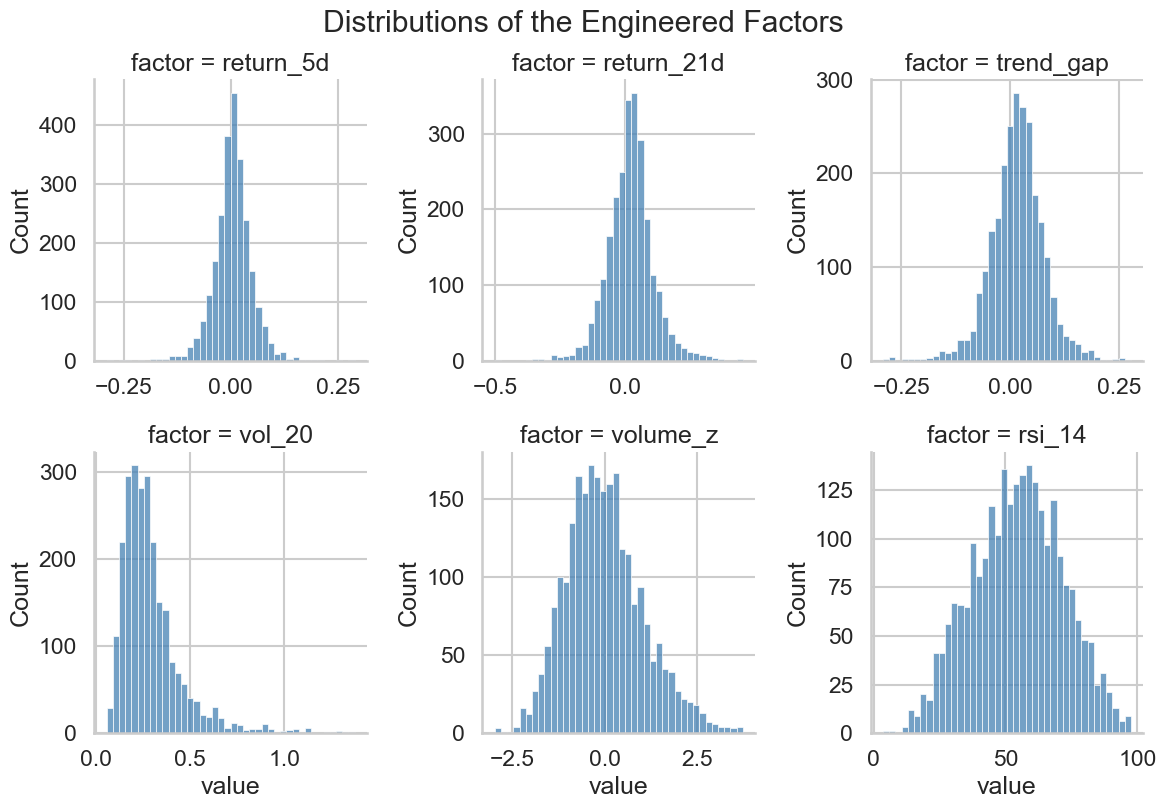

In [20]:
plot_frame = model_data[feature_columns].copy()  # Copy the factors we want to visualize.
plot_frame = plot_frame.sample(min(2500, len(plot_frame)), random_state=42)  # Sample rows so plots stay readable.
long_plot_frame = plot_frame.melt(var_name="factor", value_name="value")  # Reshape to long format for faceted plotting.

g = sns.FacetGrid(  # Build one histogram panel per factor.
    long_plot_frame,
    col="factor",
    col_wrap=3,
    sharex=False,
    sharey=False,
    height=4,
)
g.map_dataframe(sns.histplot, x="value", bins=40, color="steelblue")
g.fig.suptitle("Distributions of the Engineered Factors", y=1.02)
plt.show()

## Chapter 19. Visualize Factor Correlations

Correlation does not automatically imply redundancy.
But highly correlated factors can make interpretation harder.

This heatmap is descriptive, not causal.

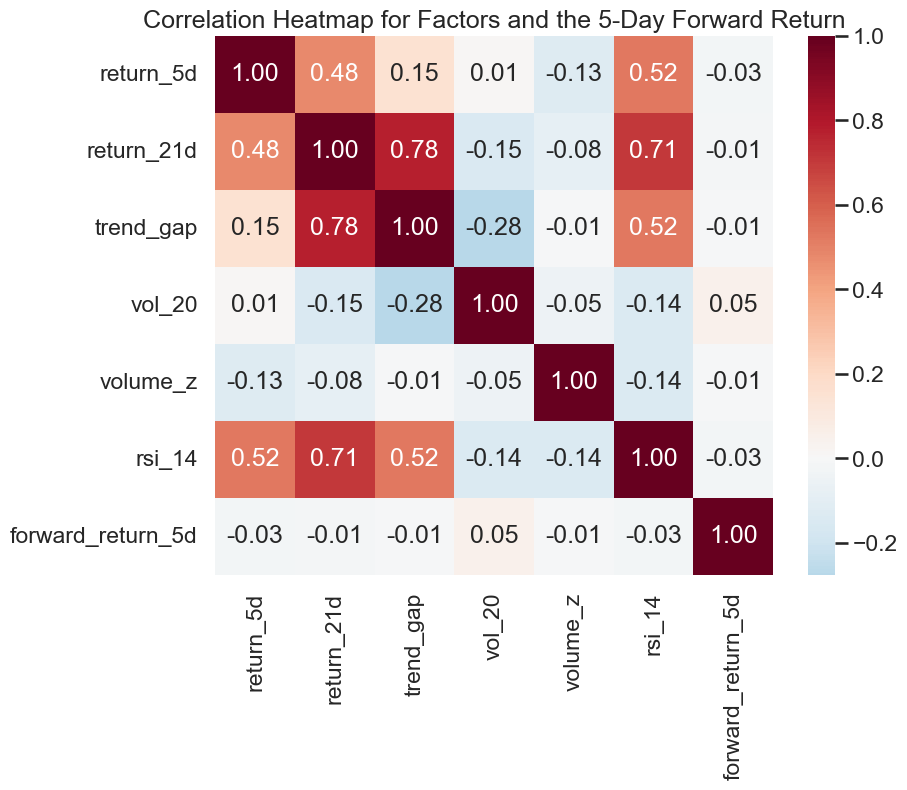

In [21]:
correlation_matrix = model_data[feature_columns + ["forward_return_5d"]].corr(numeric_only=True)  # Compute pairwise linear correlations.

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
)
plt.title("Correlation Heatmap for Factors and the 5-Day Forward Return")
plt.show()

## Chapter 20. Plot a Few Feature-vs-Target Relationships

These plots are useful for intuition.
They are **not** proof of causality.

A visible slope in an observational scatter plot can still be driven by:

- omitted variables,
- regime shifts,
- selection effects,
- or pure chance.

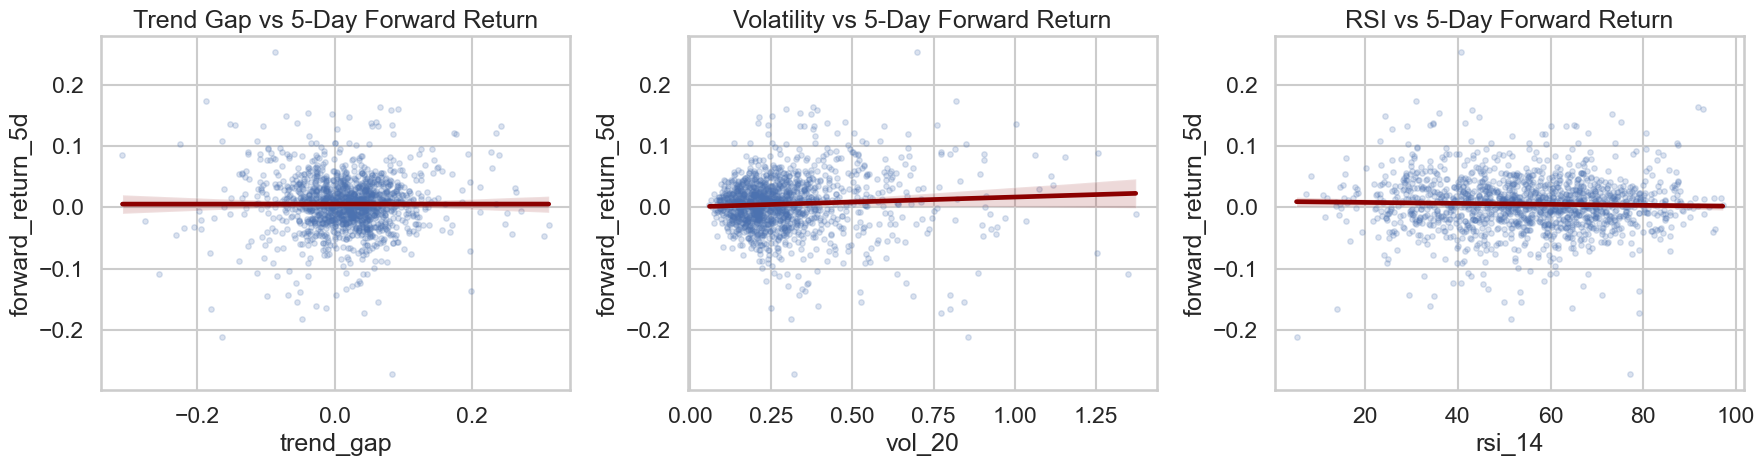

In [22]:
scatter_sample = model_data.sample(min(1500, len(model_data)), random_state=7)  # Sample rows so the scatter is easier to see.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(
    data=scatter_sample,
    x="trend_gap",
    y="forward_return_5d",
    scatter_kws={"alpha": 0.20, "s": 15},
    line_kws={"color": "darkred"},
    ax=axes[0],
)
axes[0].set_title("Trend Gap vs 5-Day Forward Return")

sns.regplot(
    data=scatter_sample,
    x="vol_20",
    y="forward_return_5d",
    scatter_kws={"alpha": 0.20, "s": 15},
    line_kws={"color": "darkred"},
    ax=axes[1],
)
axes[1].set_title("Volatility vs 5-Day Forward Return")

sns.regplot(
    data=scatter_sample,
    x="rsi_14",
    y="forward_return_5d",
    scatter_kws={"alpha": 0.20, "s": 15},
    line_kws={"color": "darkred"},
    ax=axes[2],
)
axes[2].set_title("RSI vs 5-Day Forward Return")

plt.tight_layout()
plt.show()

## Chapter 21. A Causality Interlude

This is the right place to pause and say something very important.

### What we are doing

We are using historical observational data to build a predictive trading model.

### What we are **not** doing

We are **not** randomly assigning assets to different volatility levels, momentum states, or liquidity conditions.
Markets are not laboratory mice.

### Why that matters

If a factor appears important, there are several possibilities:

- the factor may capture a genuine causal driver,
- the factor may merely proxy for another hidden cause,
- the factor may work only in one regime,
- the factor may reflect data mining luck,
- or the model may be exploiting a structural feature that later disappears.

### So why do the stress tests at all?

Because scenario analysis is still useful.
Even when it is not a clean causal identification strategy, it helps us ask:

- Which signals is the strategy most sensitive to?
- If volatility suddenly increases, does the system become fragile?
- If momentum flips, what happens?

That is valuable for decision-making, even without claiming causal proof.

In [23]:
volatility_bucket_summary = (
    model_data.assign(  # Create a temporary bucketed version of the data.
        vol_bucket=pd.qcut(model_data["vol_20"], q=5, duplicates="drop")  # Split volatility into quantile buckets.
    )
    .groupby("vol_bucket")["forward_return_5d"]  # For each volatility bucket...
    .mean()  # ...compute the average future return.
    .to_frame("mean_forward_return_5d")
)

trend_bucket_summary = (
    model_data.assign(
        trend_bucket=pd.qcut(model_data["trend_gap"], q=5, duplicates="drop")
    )
    .groupby("trend_bucket")["forward_return_5d"]
    .mean()
    .to_frame("mean_forward_return_5d")
)

print("Average future return by volatility bucket:")
display(volatility_bucket_summary)

print("Average future return by trend-gap bucket:")
display(trend_bucket_summary)

Average future return by volatility bucket:


,mean_forward_return_5d
vol_bucket,
"(0.0467, 0.172]",0.003240
"(0.172, 0.224]",0.003949
"(0.224, 0.279]",0.003259
"(0.279, 0.369]",0.004281
"(0.369, 1.381]",0.008895


Average future return by trend-gap bucket:


,mean_forward_return_5d
trend_bucket,
"(-0.35, -0.0278]",0.006109
"(-0.0278, 0.00527]",0.004614
"(0.00527, 0.0302]",0.003787
"(0.0302, 0.0597]",0.003345
"(0.0597, 0.311]",0.005768


# Part V. Train/Test Logic and Leakage Prevention

## Chapter 22. Why Time Splits Matter

In finance, train/test splitting is different from many standard machine-learning examples.

We do **not** want to randomly shuffle rows, because that would let information from the future leak into the past.

Instead we use a temporal split:

- train on dates before `2024-01-01`,
- test on dates on or after `2024-01-01`.

This better matches the real decision problem: learn from history, then act in a later period.

In [24]:
train_df = model_data.loc[model_data["date"] < pd.Timestamp(test_start)].copy()  # Everything before the split is training data.
test_df = model_data.loc[model_data["date"] >= pd.Timestamp(test_start)].copy()  # Everything from the split onward is test data.

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train date range:", train_df["date"].min(), "->", train_df["date"].max())
print("Test date range:", test_df["date"].min(), "->", test_df["date"].max())
print("Unique train symbols:", train_df["symbol"].nunique())
print("Unique test symbols:", test_df["symbol"].nunique())

Train rows: 17520
Test rows: 6737
Train date range: 2018-03-14 00:00:00 -> 2023-12-29 00:00:00
Test date range: 2024-01-02 00:00:00 -> 2026-03-30 00:00:00
Unique train symbols: 12
Unique test symbols: 12


# Part VI. Plug the Factors into the Algorithmic Trading System

## Chapter 23. What the Trading System Does

The reusable `AlgorithmicTradingSystem` follows a simple logic:

1. fit a machine-learning model to predict 5-day forward returns from the factors,
2. score each asset each day,
3. rank the assets cross-sectionally on that day,
4. go relatively long the stronger-ranked assets,
5. go relatively short the weaker-ranked assets.

The strategy is therefore:

- **predictive**, not causal,
- **cross-sectional**, because it compares assets to one another on the same day,
- **rank-based**, because position decisions come from relative ranking rather than raw predicted values.

In [25]:
strategy = AlgorithmicTradingSystem(  # Create the reusable strategy object.
    feature_columns=feature_columns,  # Tell the strategy which columns contain the factors.
    buy_threshold=0.55,  # Assets with rank percentiles above this threshold become long candidates.
    short_threshold=0.45,  # Assets with rank percentiles below this threshold become short candidates.
    max_leverage=1.0,  # Gross exposure is normalized to 1.0 each day.
)

strategy

In [26]:
strategy.fit(train_df)  # Fit the random-forest model on the historical training sample.

strategy.model.get_params()  # Inspect the model hyperparameters so the process is not a black box.

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 6,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 8,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 300,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

## Chapter 24. Convert Model Scores into Portfolio Returns

This is a subtle but extremely important step.

The model gives us an asset-level score.
But the portfolio earns a **daily portfolio return**.

That means we must:

1. compute positions for each asset on each day,
2. multiply each position by the next day's realized return,
3. **sum** those asset-level contributions by date to get the actual strategy return.

Why sum and not average?

Because the asset-level `position` values are portfolio weights.
The daily portfolio return is the weighted sum of constituent returns.

In [27]:
def apply_strategy_to_frame(frame: pd.DataFrame, fitted_strategy: AlgorithmicTradingSystem) -> pd.DataFrame:
    """Apply a fitted strategy to a feature table and keep the asset-level results."""

    results = frame.copy()  # Start from a copy so the original data frame stays untouched.
    results["position"] = fitted_strategy.generate_positions(results)  # Compute long/short weights for every symbol-date row.
    results["next_day_return"] = results.groupby("symbol")["return_1d"].shift(-1)  # Realized return after today's signal is tomorrow's return.
    results["strategy_return"] = results["position"] * results["next_day_return"]  # Each row contributes weight times realized return.
    results["benchmark_return"] = results.groupby("date")["next_day_return"].transform("mean")  # Benchmark is the equal-weight average return that day.
    results = results.dropna(subset=["next_day_return"]).reset_index(drop=True)  # Drop rows where we cannot observe the next day.
    return results


def build_daily_portfolio(asset_level_results: pd.DataFrame) -> pd.DataFrame:
    """Aggregate asset-level contributions into daily portfolio results."""

    daily = (
        asset_level_results.groupby("date")  # Move from asset rows to one row per day.
        .agg(
            strategy_return=("strategy_return", "sum"),  # Sum weighted asset contributions to get the portfolio return.
            benchmark_return=("benchmark_return", "mean"),  # Mean benchmark return because the benchmark is equal-weighted.
        )
        .reset_index()
        .sort_values("date")
    )

    daily["strategy_equity"] = (1 + daily["strategy_return"]).cumprod()  # Grow $1 through time under the strategy.
    daily["benchmark_equity"] = (1 + daily["benchmark_return"]).cumprod()  # Grow $1 through time under the benchmark.
    daily["strategy_drawdown"] = daily["strategy_equity"] / daily["strategy_equity"].cummax() - 1  # Distance below the previous equity peak.
    daily["benchmark_drawdown"] = daily["benchmark_equity"] / daily["benchmark_equity"].cummax() - 1

    return daily

In [28]:
train_results = apply_strategy_to_frame(train_df, strategy)  # Apply the fitted system to the training set.
test_results = apply_strategy_to_frame(test_df, strategy)  # Apply the fitted system to the out-of-sample test set.

train_results.head(10)

,date,symbol,close,volume,return_1d,return_5d,return_21d,trend_gap,vol_20,volume_z,rsi_14,forward_return_5d,position,next_day_return,strategy_return,benchmark_return
0,2018-03-14,AAPL,41.920341,117473600,-0.008501,0.019482,0.096675,0.033338,0.201436,-0.810849,62.364585,-0.040181,-0.090909,0.001177,-0.000107,0.003864
1,2018-03-15,AAPL,41.969685,90975200,0.001177,0.009664,0.087076,0.034608,0.194452,-1.799108,57.418882,-0.054856,-0.083333,-0.003527,0.000294,0.003499
2,2018-03-16,AAPL,41.821674,157618800,-0.003527,-0.010890,0.063632,0.034879,0.159354,0.891392,47.417045,-0.073475,-0.090909,-0.015279,0.001389,-0.022777
3,2018-03-19,AAPL,41.182674,133787200,-0.015279,-0.035329,0.013353,0.033639,0.169494,0.103828,42.474433,-0.014432,-0.090909,-0.000342,0.000031,0.004889
4,2018-03-20,AAPL,41.168579,78597600,-0.000342,-0.026282,0.016296,0.032695,0.168829,-2.184952,42.913331,-0.039374,0.090909,-0.022654,-0.002059,-0.002359
5,2018-03-21,AAPL,40.235931,148219600,-0.022654,-0.040181,-0.003375,0.030797,0.187922,0.677688,41.190372,-0.027968,-0.090909,-0.014130,0.001285,-0.028768
6,2018-03-22,AAPL,39.667400,165963200,-0.014130,-0.054856,-0.012977,0.026669,0.191768,1.085596,33.556658,-0.006337,-0.090909,-0.023157,0.002105,-0.024184
7,2018-03-23,AAPL,38.748837,164115200,-0.023157,-0.073475,-0.043826,0.018956,0.194192,0.969219,26.869197,0.010549,-0.090909,0.047472,-0.004316,0.034277
8,2018-03-26,AAPL,40.588322,150164800,0.047472,-0.014432,-0.015555,0.013964,0.253240,0.595966,44.154675,-0.025352,-0.090909,-0.025641,0.002331,-0.027950
9,2018-03-27,AAPL,39.547592,163690400,-0.025641,-0.039374,-0.059395,0.008142,0.267213,0.944263,40.746919,0.019425,-0.090909,-0.011049,0.001004,-0.007432


In [29]:
test_results.head(10)

,date,symbol,close,volume,return_1d,return_5d,return_21d,trend_gap,vol_20,volume_z,rsi_14,forward_return_5d,position,next_day_return,strategy_return,benchmark_return
0,2024-01-02,AAPL,183.731293,82488700,-0.035787,-0.041116,-0.022690,0.035448,0.191686,1.384963,31.663560,-0.002693,-0.090909,-0.007487,0.000681,-0.002586
1,2024-01-03,AAPL,182.355621,58414500,-0.007487,-0.045584,-0.036551,0.027939,0.190711,0.311444,24.387914,0.010529,-0.090909,-0.012700,0.001155,-0.002707
2,2024-01-04,AAPL,180.039673,71983600,-0.012700,-0.058193,-0.039698,0.018906,0.175187,0.917890,8.867340,0.020230,0.090909,-0.004013,-0.000365,0.004105
3,2024-01-05,AAPL,179.317139,62379700,-0.004013,-0.064056,-0.063282,0.010753,0.174948,0.434641,7.864709,0.026162,0.100000,0.024175,0.002417,0.015982
4,2024-01-08,AAPL,183.652115,59144500,0.024175,-0.036202,-0.035150,0.004311,0.194811,0.242227,24.906034,-0.010401,-0.100000,-0.002263,0.000226,0.001026
5,2024-01-09,AAPL,183.236435,42841800,-0.002263,-0.002693,-0.046997,-0.002163,0.191465,-0.686812,26.290337,-0.013287,-0.111111,0.005671,-0.000630,0.009467
6,2024-01-10,AAPL,184.275635,46792900,0.005671,0.010529,-0.048643,-0.007732,0.189666,-0.385090,26.290186,0.013105,0.000000,-0.003222,-0.000000,0.001916
7,2024-01-11,AAPL,183.681839,49128400,-0.003222,0.020230,-0.039290,-0.013371,0.186205,-0.229622,28.166323,0.032167,0.090909,0.001778,0.000162,-0.000167
8,2024-01-12,AAPL,184.008423,40477800,0.001778,0.026162,-0.045144,-0.019030,0.173061,-0.725823,29.475116,0.042868,0.090909,-0.012317,-0.001120,-0.005538
9,2024-01-16,AAPL,181.741989,65603000,-0.012317,-0.010401,-0.072388,-0.024760,0.175427,0.718426,27.893524,0.062898,0.090909,-0.005173,-0.000470,-0.005965


In [30]:
train_daily = build_daily_portfolio(train_results)  # Aggregate the training asset-level contributions to daily returns.
test_daily = build_daily_portfolio(test_results)  # Aggregate the test asset-level contributions to daily returns.

test_daily.head(10)

,date,strategy_return,benchmark_return,strategy_equity,benchmark_equity,strategy_drawdown,benchmark_drawdown
0,2024-01-02,-0.008843,-0.002586,0.991157,0.997414,0.000000,0.000000
1,2024-01-03,0.004684,-0.002707,0.995799,0.994714,0.000000,-0.002707
2,2024-01-04,-0.001833,0.004105,0.993974,0.998798,-0.001833,0.000000
3,2024-01-05,-0.008399,0.015982,0.985625,1.014760,-0.010216,0.000000
4,2024-01-08,-0.001775,0.001026,0.983876,1.015802,-0.011973,0.000000
5,2024-01-09,0.001090,0.009467,0.984948,1.025418,-0.010896,0.000000
6,2024-01-10,-0.002803,0.001916,0.982187,1.027383,-0.013669,0.000000
7,2024-01-11,0.002490,-0.000167,0.984633,1.027211,-0.011213,-0.000167
8,2024-01-12,-0.003705,-0.005538,0.980985,1.021523,-0.014876,-0.005704
9,2024-01-16,-0.005141,-0.005965,0.975942,1.015429,-0.019941,-0.011635


## Chapter 25. Compute Standard Portfolio Metrics

We will use the shared helper `evaluate_performance`, which computes:

- annualized return,
- annualized volatility,
- Sharpe ratio,
- maximum drawdown,
- hit rate,
- cumulative return.

These metrics are based on the daily aggregated portfolio returns, not the raw asset-level rows.

In [31]:
train_metrics = evaluate_performance(train_results, label="train")  # Summarize in-sample behavior.
test_metrics = evaluate_performance(test_results, label="test")  # Summarize out-of-sample behavior.

metrics = pd.DataFrame(  # Put both dictionaries into one tidy table.
    {
        "train": train_metrics,
        "test": test_metrics,
    }
).T

metrics

,label,annual_return,annual_volatility,sharpe_ratio,max_drawdown,hit_rate,cumulative_return
train,train,0.232683,0.089163,2.609626,-0.062775,0.556546,2.357384
test,test,0.008185,0.088777,0.0922,-0.184395,0.518717,0.018314


## Chapter 26. Plot the Equity Curves

The equity curve is often the most intuitive plot in a backtest.
It answers a simple question:

“If I started with $1, what would happen over time?”

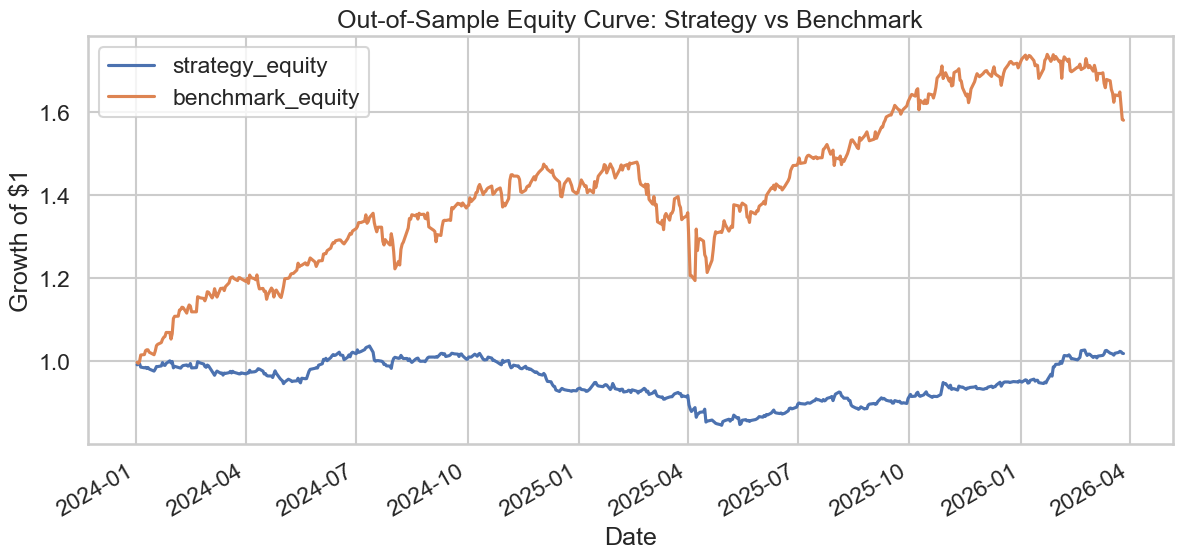

In [32]:
ax = test_daily.plot(
    x="date",
    y=["strategy_equity", "benchmark_equity"],
    figsize=(14, 6),
    title="Out-of-Sample Equity Curve: Strategy vs Benchmark",
)
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
plt.show()

## Chapter 27. Plot the Drawdowns

A strategy can have a good long-run return and still be psychologically or economically difficult to hold.

Drawdown tells us how painful the ride is between peaks.

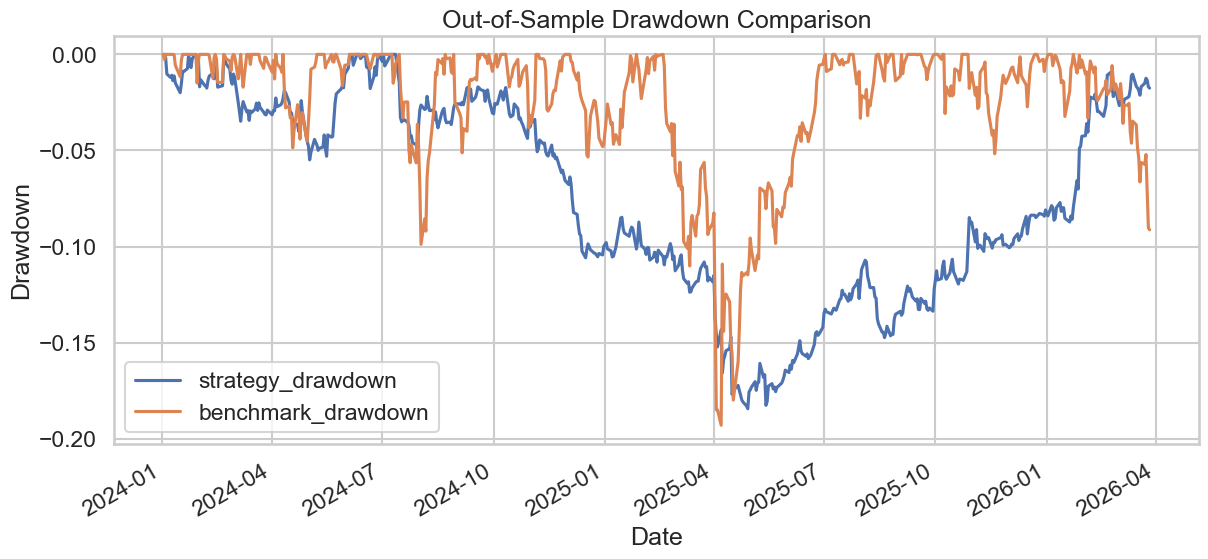

In [33]:
ax = test_daily.plot(
    x="date",
    y=["strategy_drawdown", "benchmark_drawdown"],
    figsize=(14, 6),
    title="Out-of-Sample Drawdown Comparison",
)
ax.set_ylabel("Drawdown")
ax.set_xlabel("Date")
plt.show()

## Chapter 28. Inspect the Worst Days

Summary metrics are useful.
But debugging often starts with the tails.

Looking at the worst days helps us ask:

- Did the strategy suffer during volatility spikes?
- Did it fail in sector-specific shocks?
- Were losses broad or concentrated?

In [34]:
test_daily.nsmallest(10, "strategy_return")

,date,strategy_return,benchmark_return,strategy_equity,benchmark_equity,strategy_drawdown,benchmark_drawdown
323,2025-04-16,-0.035101,-0.005465,0.853131,1.249638,-0.176919,-0.155571
317,2025-04-08,-0.026273,0.103942,0.864708,1.318392,-0.165750,-0.109112
313,2025-04-02,-0.024852,-0.057301,0.894478,1.279999,-0.137029,-0.135056
342,2025-05-14,-0.019131,-0.009524,0.847226,1.361073,-0.182616,-0.080271
134,2024-07-16,-0.018501,-0.016989,1.002462,1.333481,-0.032849,-0.016989
21,2024-02-01,-0.015400,0.034561,0.983799,1.102908,-0.016875,0.000000
133,2024-07-15,-0.014618,0.007797,1.021358,1.356527,-0.014618,0.000000
197,2024-10-14,-0.013961,-0.016981,1.004389,1.401647,-0.030989,-0.016981
42,2024-03-04,-0.013285,-0.011861,0.975534,1.152360,-0.025133,-0.012733
81,2024-04-29,-0.012566,-0.012786,0.958508,1.156337,-0.042148,-0.042629


# Part VII. Which Factors Mattered Most?

## Chapter 29. Permutation Importance

Permutation importance is a predictive importance tool.
It asks:

“If I scramble one factor so the model can no longer use its information, how much worse does prediction get?”

This is still **not a causal effect estimate**.
It is a measure of the model's reliance on that factor within this predictive setup.

In [35]:
factor_importance = compute_factor_importance(  # Measure how much each factor matters to model prediction quality.
    strategy=strategy,
    train_df=train_df,
    feature_columns=feature_columns,
)

factor_importance

,factor,importance_mean,importance_std
0,vol_20,0.000119,3.697953e-06
1,trend_gap,0.000044,1.966853e-06
2,rsi_14,0.000043,2.698263e-06
3,return_21d,0.000029,1.341727e-06
4,return_5d,0.000022,9.719584e-07
5,volume_z,0.000010,7.734221e-07


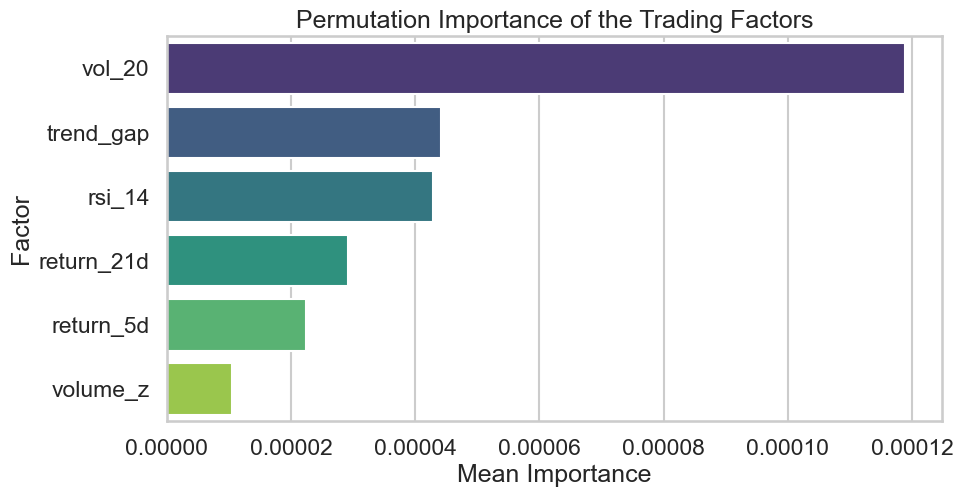

In [36]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=factor_importance,
    x="importance_mean",
    y="factor",
    hue="factor",
    palette="viridis",
    legend=False,
)
plt.title("Permutation Importance of the Trading Factors")
plt.xlabel("Mean Importance")
plt.ylabel("Factor")
plt.show()

# Part VIII. Counterfactual Stress Analysis

## Chapter 30. What We Mean by “Counterfactual” Here

In strict causal inference, a counterfactual asks what would have happened under an alternative intervention.

In a financial notebook like this, we usually do something more modest:

- perturb the features in a way that resembles a market regime shift,
- rerun the strategy logic,
- measure how the portfolio outcome changes.

This is **stress testing informed by counterfactual thinking**.
It is useful, but it is not a clean identification design.

In [37]:
scenarios = {  # Each scenario nudges one or more factors in a market-intuitive direction.
    "higher_volatility": {"vol_20": 1.35},  # Increase recent volatility by 35%.
    "momentum_crash": {  # Reverse recent momentum-style features.
        "return_5d": -1.0,
        "return_21d": -1.0,
        "trend_gap": -0.75,
    },
    "liquidity_shock": {"volume_z": -2.0},  # Force a sharp negative liquidity surprise.
    "oversold_mean_reversion": {  # Push RSI lower and weaken short-horizon returns.
        "rsi_14": -20.0,
        "return_5d": -0.5,
    },
}

scenarios

{'higher_volatility': {'vol_20': 1.35},
 'momentum_crash': {'return_5d': -1.0, 'return_21d': -1.0, 'trend_gap': -0.75},
 'liquidity_shock': {'volume_z': -2.0},
 'oversold_mean_reversion': {'rsi_14': -20.0, 'return_5d': -0.5}}

In [38]:
stress_rows = []  # We will collect one summary row per scenario.

baseline_cumulative_return = test_metrics["cumulative_return"]  # We compare every scenario against the base-case strategy result.
baseline_max_drawdown = test_metrics["max_drawdown"]  # We also compare drawdowns against the base case.

for scenario_name, adjustments in scenarios.items():  # Loop through the scenario dictionary one scenario at a time.
    shocked_test_df = apply_counterfactual(  # Perturb the factor columns according to the scenario definition.
        df=test_df,
        adjustments=adjustments,
        feature_columns=feature_columns,
    )

    shocked_results = apply_strategy_to_frame(  # Re-run the already-fitted strategy on the shocked factor table.
        shocked_test_df,
        strategy,
    )

    shocked_metrics = evaluate_performance(  # Summarize the shocked strategy outcome.
        shocked_results,
        label=scenario_name,
    )

    stress_rows.append(  # Store the scenario summary for later plotting and interpretation.
        {
            "scenario": scenario_name,
            "annual_return": shocked_metrics["annual_return"],
            "annual_volatility": shocked_metrics["annual_volatility"],
            "sharpe_ratio": shocked_metrics["sharpe_ratio"],
            "max_drawdown": shocked_metrics["max_drawdown"],
            "cumulative_return": shocked_metrics["cumulative_return"],
            "return_delta_vs_baseline": shocked_metrics["cumulative_return"] - baseline_cumulative_return,
            "drawdown_delta_vs_baseline": shocked_metrics["max_drawdown"] - baseline_max_drawdown,
        }
    )

stress_summary = pd.DataFrame(stress_rows).sort_values("return_delta_vs_baseline").reset_index(drop=True)

stress_summary

,scenario,annual_return,annual_volatility,sharpe_ratio,max_drawdown,cumulative_return,return_delta_vs_baseline,drawdown_delta_vs_baseline
0,momentum_crash,0.031275,0.086884,0.359962,-0.086613,0.070962,0.052648,0.097781
1,liquidity_shock,0.057376,0.089342,0.642204,-0.118082,0.132242,0.113929,0.066312
2,higher_volatility,0.070468,0.085428,0.824872,-0.168191,0.163687,0.145374,0.016204
3,oversold_mean_reversion,0.204777,0.086764,2.360159,-0.070366,0.513956,0.495643,0.114029


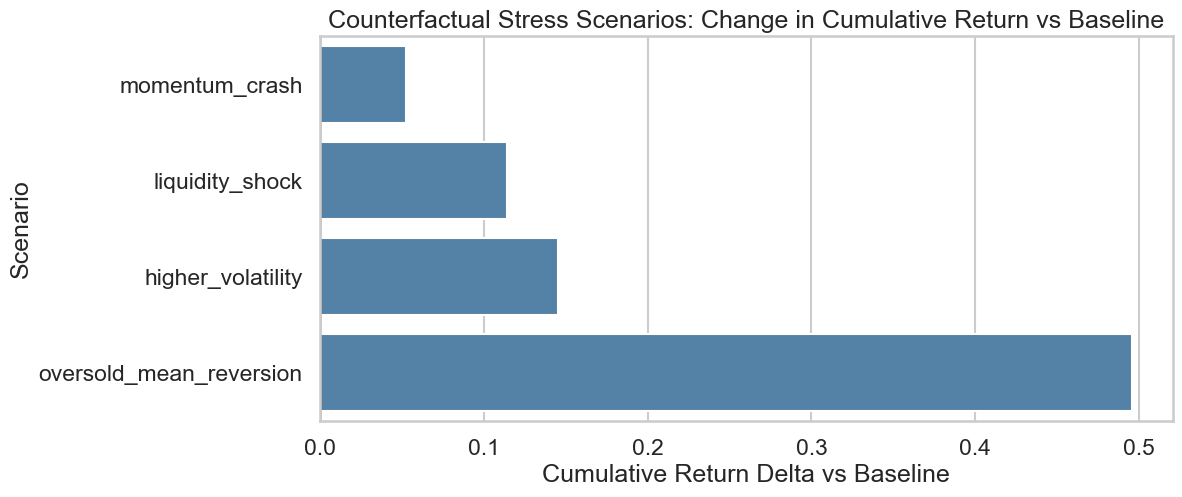

In [39]:
plt.figure(figsize=(11, 5))
sns.barplot(
    data=stress_summary,
    x="return_delta_vs_baseline",
    y="scenario",
    color="steelblue",
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Counterfactual Stress Scenarios: Change in Cumulative Return vs Baseline")
plt.xlabel("Cumulative Return Delta vs Baseline")
plt.ylabel("Scenario")
plt.show()

## Chapter 31. How to Read the Stress Table

If a scenario has:

- a **negative** `return_delta_vs_baseline`, the strategy did worse than in the original test,
- a **more negative** `max_drawdown`, the strategy suffered a deeper drawdown,
- a much lower Sharpe ratio, risk-adjusted performance deteriorated.

This does not prove the stressed factor “causes” the damage in a scientific sense.
It shows that the strategy's behavior is sensitive to that modeled market condition.

# Part IX. Re-Test on the Most Recent Window

## Chapter 32. Why Re-Test Recent Data Separately?

Financial regimes change.

A strategy can look fine over a long history and still be weak in the most recent period.
By isolating the latest window, we get a rough answer to a practical question:

“Is the strategy still behaving reasonably lately?”

In [40]:
recent_window = summarize_recent_window(  # Collapse to the recent out-of-sample daily portfolio history.
    results=test_results,
    months=recent_months,
)

print("Recent window rows:", len(recent_window))
recent_window.tail(10)

Recent window rows: 125


,date,strategy_return,benchmark_return,strategy_equity,benchmark_equity,strategy_drawdown,benchmark_drawdown
115,2026-03-16,-0.006391,-0.001913,1.132836,1.043056,-0.016645,-0.036614
116,2026-03-17,-0.000839,-0.012448,1.131885,1.030072,-0.017470,-0.048606
117,2026-03-18,-0.001246,-0.005310,1.130474,1.024602,-0.018695,-0.053658
118,2026-03-19,-0.002593,-0.013445,1.127543,1.010827,-0.021239,-0.066382
119,2026-03-20,0.004453,0.010877,1.132564,1.021821,-0.016881,-0.056226
120,2026-03-23,0.001902,-0.001083,1.134718,1.020715,-0.015011,-0.057249
121,2026-03-24,0.002613,0.005456,1.137683,1.026284,-0.012437,-0.052105
122,2026-03-25,-0.000993,-0.020587,1.136554,1.005156,-0.013417,-0.071619
123,2026-03-26,-0.003549,-0.020108,1.132521,0.984944,-0.016918,-0.090287
124,2026-03-27,-0.000648,-0.001094,1.131787,0.983867,-0.017555,-0.091282


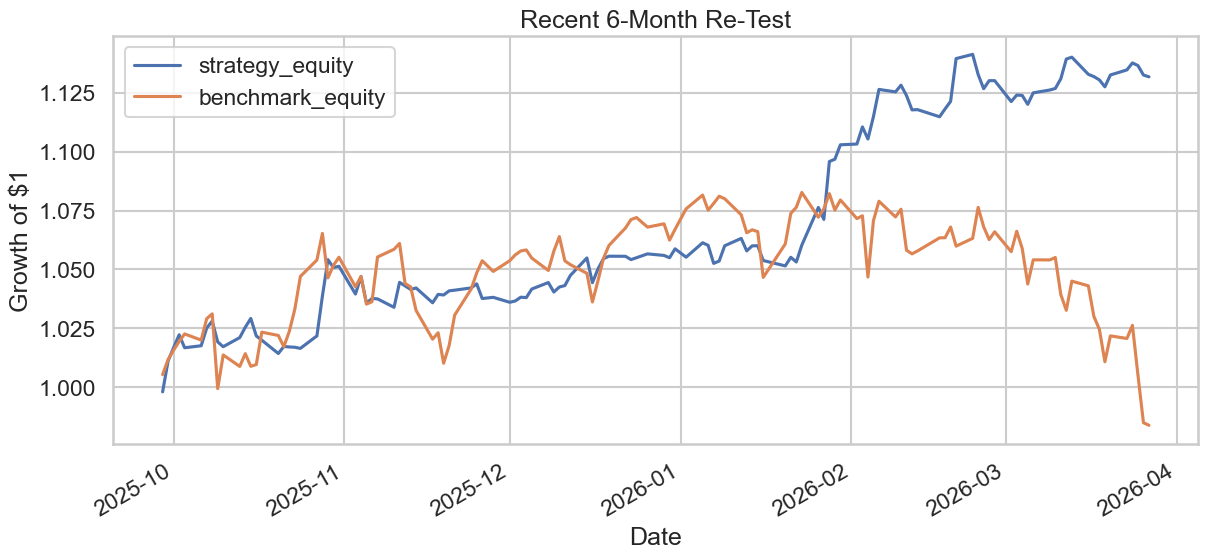

In [41]:
ax = recent_window.plot(
    x="date",
    y=["strategy_equity", "benchmark_equity"],
    figsize=(14, 6),
    title=f"Recent {recent_months}-Month Re-Test",
)
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
plt.show()

In [42]:
recent_summary = pd.Series(  # A compact summary for the most recent window.
    {
        "recent_strategy_return": recent_window["strategy_equity"].iloc[-1] - 1,
        "recent_benchmark_return": recent_window["benchmark_equity"].iloc[-1] - 1,
        "recent_alpha": recent_window["strategy_equity"].iloc[-1] - recent_window["benchmark_equity"].iloc[-1],
    }
)

recent_summary

recent_strategy_return     0.131787
recent_benchmark_return   -0.016133
recent_alpha               0.147920
dtype: float64

# Part X. What We Learned, and What We Still Do Not Know

## Chapter 33. Main Lessons

We built a complete research pipeline:

1. downloaded historical market data,
2. engineered interpretable trading factors,
3. trained a ranking-based trading system,
4. evaluated it on a later out-of-sample window,
5. measured factor importance,
6. stress-tested the strategy with counterfactual-style feature shocks,
7. and re-evaluated behavior on the most recent months.

## Chapter 34. What This Notebook Does **Not** Prove

This notebook does **not** prove:

- that the factors are true causal drivers,
- that the future will look like the past,
- that the strategy will survive transaction costs, slippage, and market impact,
- that the model is robust to universe changes,
- or that observed predictive importance is the same as economic mechanism.

## Chapter 35. What a More Advanced Version Would Add

A more professional research stack would likely add:

- transaction costs and slippage,
- walk-forward retraining,
- exposure controls,
- sector neutrality,
- turnover analysis,
- richer benchmarks,
- and more careful causal identification if the goal were explanation rather than prediction.

The important habit is this:
be ambitious in experimentation, but humble in interpretation.

In [43]:
debug_objects = {  # Keep a small index of the most useful notebook objects for later debugging.
    "raw_data": raw_data,
    "coverage_summary": coverage_summary,
    "factor_data": factor_data,
    "model_data": model_data,
    "train_df": train_df,
    "test_df": test_df,
    "train_results": train_results,
    "test_results": test_results,
    "train_daily": train_daily,
    "test_daily": test_daily,
    "factor_importance": factor_importance,
    "stress_summary": stress_summary,
    "recent_window": recent_window,
}

list(debug_objects.keys())

['raw_data',
 'coverage_summary',
 'factor_data',
 'model_data',
 'train_df',
 'test_df',
 'train_results',
 'test_results',
 'train_daily',
 'test_daily',
 'factor_importance',
 'stress_summary',
 'recent_window']